In [ ]:
#Schritt 1
import os   #Zugriff auf Ordner, Dateien einlesen
import matplotlib.pyplot as plt #Diagramme und Bilder anzeigen
from PIL import Image   #Bilder öffnen, bearbeiten, verarbeiten

In [ ]:
#Schritt 2
DATASET_DIR = "dataset-resized"

# Prüfen, ob der Ordner mit den Müllbildern existiert
print("Ordner gefunden:", os.path.isdir(DATASET_DIR))


Ordner gefunden: True


In [ ]:
# kann ggf. weg war um fehler zu behandeln
import os

# Das Notebook-Verzeichnis als Arbeitsverzeichnis setzen
os.chdir(os.getcwd())

# Zeige das aktuelle Arbeitsverzeichnis
print(os.getcwd())

# Zeige Inhalte des Verzeichnisses
print(os.listdir())


c:\Users\GOICY\OneDrive - Bayer\00 Persönlich\03 FHDW\Data Lab\DataLabTrash\src
['Lisa.ipynb', 'muellerkennung.ipynb']


In [ ]:
# kann ggf. weg war um fehler zu behandeln
import os

os.chdir(r"c:\Users\GOICY\OneDrive - Bayer\00 Persönlich\03 FHDW\Data Lab\DataLabTrash")

# danach prüfen:
print(os.listdir())


['.git', 'dataset-resized', 'README.md', 'requirements.txt', 'src']


In [18]:
DATASET_DIR = "dataset-resized"
print(os.path.isdir(DATASET_DIR))

True


In [20]:
# SCHRITT 3 — Klassen automatisch aus den Ordnern einlesen
# Alle Ordner im Dataset als Klassen einlesen
classes = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])

classes

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

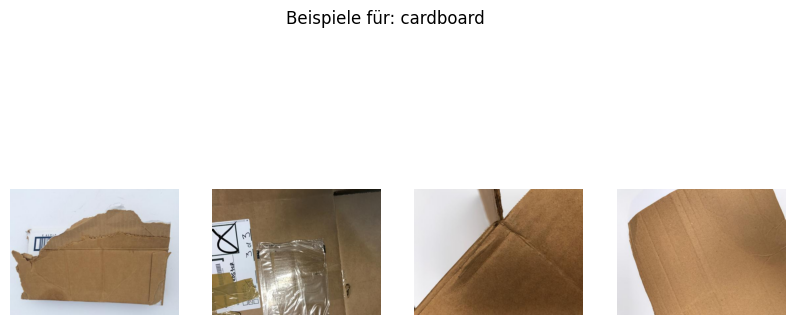

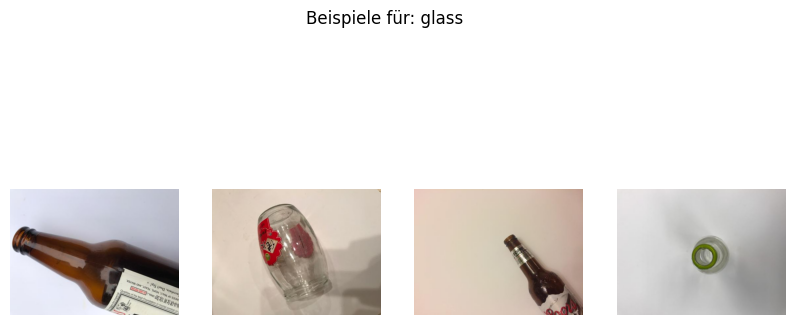

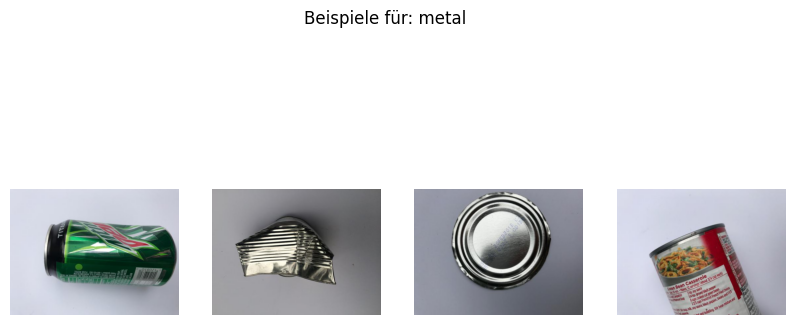

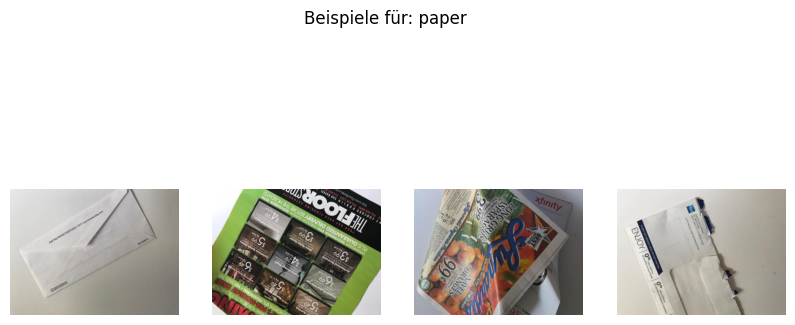

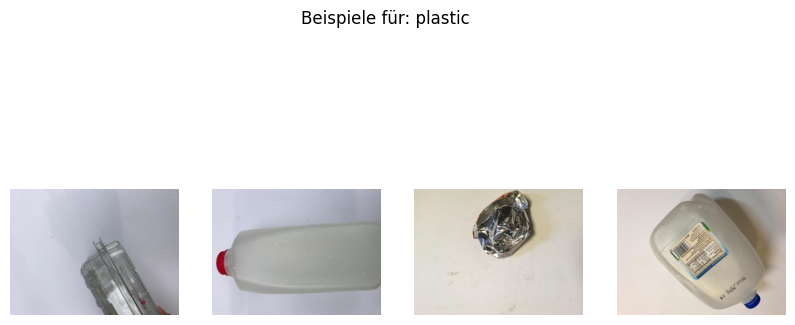

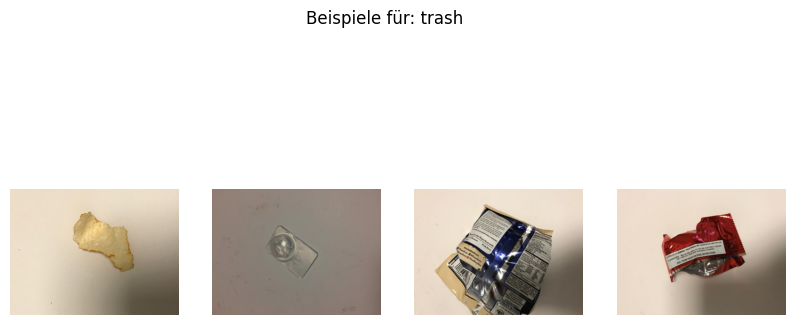

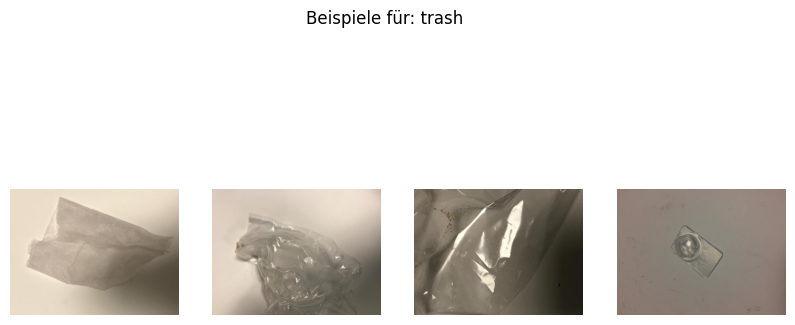

In [ ]:
#Beispielbilder jeder Klasse aus dem  Datensatz anzeigen
import random

def show_examples(cls, n=4):
    folder = os.path.join(DATASET_DIR, cls)
    files = random.sample(os.listdir(folder), n)

    plt.figure(figsize=(10, 5))

    for i, file in enumerate(files):
        img_path = os.path.join(folder, file)
        img = Image.open(img_path)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(f"Beispiele für: {cls}")
    plt.show()

# Beispiel: zeige 4 Bilder der ersten Klasse
show_examples(classes[0])
show_examples(classes[1])
show_examples(classes[2])
show_examples(classes[3])
show_examples(classes[4])
show_examples(classes[5])
#show_examples("trash")

In [30]:
#Schritt 5a
# Größe eines Beispielbilds anzeigen
sample_class = classes[0]  # erste Klasse, z. B. cardboard
sample_file = os.listdir(os.path.join(DATASET_DIR, sample_class))[0]
sample_path = os.path.join(DATASET_DIR, sample_class, sample_file)

img = Image.open(sample_path)
print("Beispielbild:", sample_path)
print("Größe:", img.size)   # (Breite, Höhe)

Beispielbild: dataset-resized\cardboard\cardboard1.jpg
Größe: (512, 384)


In [31]:
#Schritt 5b
#Größen ALLER Bilder analysieren
sizes = []

for cls in classes:
    folder = os.path.join(DATASET_DIR, cls)
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        try:
            img = Image.open(img_path)
            sizes.append(img.size)
        except:
            print("Fehler bei Datei:", img_path)



In [32]:
#Schritt 5c
#Häufigkeit der Größen auswerten
from collections import Counter

size_counts = Counter(sizes)
size_counts.most_common(10)  # die 10

[((512, 384), 2527)]

<function matplotlib.pyplot.show(close=None, block=None)>

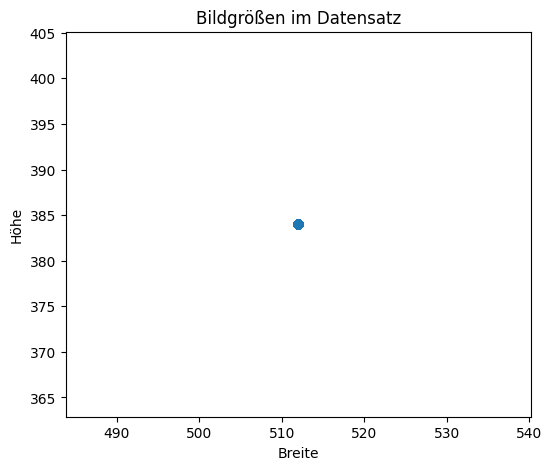

In [33]:
#Schritt 5d
#Bildgrößen als Plot anzeigen
widths = [w for (w,h) in sizes]
heights = [h for (w,h) in sizes]

plt.figure(figsize=(6,5))
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("Breite")
plt.ylabel("Höhe")
plt.title("Bildgrößen im Datensatz")
plt.show

# ERGEBNIS: Alle Bilder sind gleich groß
Wenn wir neue Bilddaten hinzufügen, müssen wir sie auf Größe prüfen und ggf. auf eine einheitliche Größe bringen

In [ ]:
#Schritt 7
#Alle Bilder auf 224x224 skalieren

from PIL import Image
import os

# Original-Ordner
INPUT_DIR = "dataset-resized"
# Ziel-Ordner
OUTPUT_DIR = "dataset-224"

# Zielgröße
TARGET_SIZE = (224, 224)

# Zielordner erstellen
os.makedirs(OUTPUT_DIR, exist_ok=True)

for cls in classes:
    # Ordner für die Klasse im Zielverzeichnis anlegen
    input_class_path = os.path.join(INPUT_DIR, cls)
    output_class_path = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(output_class_path, exist_ok=True)

    # Alle Bilder durchgehen
    for file in os.listdir(input_class_path):
        input_path = os.path.join(input_class_path, file)
        output_path = os.path.join(output_class_path, file)

        try:
            # Bild öffnen und konvertieren
            img = Image.open(input_path).convert("RGB")
            # Resizing durchführen
            img = img.resize(TARGET_SIZE)
            # Bild speichern
            img.save(output_path)
        except Exception as e:
            print("Fehler bei Datei:", input_path, "-", e)

print("Fertig! Alle Bilder wurden nach dataset-224 resized.")

Fertig! Alle Bilder wurden nach dataset-224 resized.


In [35]:
#Schritt 7 prüfen
print(os.listdir("dataset-224"))

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
#Schritt 7 prüfen: Schaut, ob gleiche viele Bilder vorher wie nachher, also keins verloren gegegangen
print(len(os.listdir("dataset-resized/cardboard")))
print(len(os.listdir("dataset-224/cardboard")))

403
403


In [38]:
#Schritt 8
#Train/Validation/Test Split automatisch erzeugen

import os
import shutil
from sklearn.model_selection import train_test_split

# Eingangsordner (resized dataset)
INPUT_DIR = "dataset-224"

# Zielordner für Split
OUTPUT_BASE = "dataset-split"

# Anteile
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

# Zielstruktur anlegen
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(OUTPUT_BASE, split, cls), exist_ok=True)

# Jeden Klassenordner durchgehen
for cls in classes:
    cls_dir = os.path.join(INPUT_DIR, cls)
    files = os.listdir(cls_dir)

    # Train/Val/Test Split
    train_files, temp_files = train_test_split(
        files, test_size=(1 - train_ratio), random_state=42
    )

    val_files, test_files = train_test_split(
        temp_files, test_size=(test_ratio / (test_ratio + val_ratio)), random_state=42
    )

    # Dateien verschieben
    for f in train_files:
        shutil.copy(os.path.join(cls_dir, f), os.path.join(OUTPUT_BASE, "train", cls, f))

    for f in val_files:
        shutil.copy(os.path.join(cls_dir, f), os.path.join(OUTPUT_BASE, "val", cls, f))

    for f in test_files:
        shutil.copy(os.path.join(cls_dir, f), os.path.join(OUTPUT_BASE, "test", cls, f))

print("Train/Val/Test Split fertig erzeugt!")


Train/Val/Test Split fertig erzeugt!


In [39]:
#Schritt 8b
#Prüfen, ob der Split funktioniert hat
for split in ["train", "val", "test"]:
    print(split)
    for cls in classes:
        count = len(os.listdir(os.path.join("dataset-split", split, cls)))
        print(f"  {cls}: {count} Bilder")

train
  cardboard: 282 Bilder
  glass: 350 Bilder
  metal: 286 Bilder
  paper: 415 Bilder
  plastic: 337 Bilder
  trash: 95 Bilder
val
  cardboard: 60 Bilder
  glass: 75 Bilder
  metal: 62 Bilder
  paper: 89 Bilder
  plastic: 72 Bilder
  trash: 21 Bilder
test
  cardboard: 61 Bilder
  glass: 76 Bilder
  metal: 62 Bilder
  paper: 90 Bilder
  plastic: 73 Bilder
  trash: 21 Bilder


In [40]:
#Schritt 9
#Datenaugmentation: Neue Bilder erstellen mit Helligkeit, Drehung, Flip, Zoom
from PIL import Image, ImageEnhance
import os
import random

INPUT_DIR = "dataset-split/train"
OUTPUT_DIR = "dataset-augmented/train"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Definiere Augmentationen
def augment_image(img):
    # leichtes Drehen
    if random.random() < 0.5:
        angle = random.randint(-15, 15)
        img = img.rotate(angle)

    # horizontales Spiegeln
    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # Helligkeit variieren
    if random.random() < 0.4:
        enhancer = ImageEnhance.Brightness(img)
        img = enhancer.enhance(random.uniform(0.7, 1.3))

    # Kontrast variieren
    if random.random() < 0.4:
        enhancer = ImageEnhance.Contrast(img)
        img = enhancer.enhance(random.uniform(0.7, 1.3))

    return img


for cls in classes:
    input_class_path = os.path.join(INPUT_DIR, cls)
    output_class_path = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(output_class_path, exist_ok=True)

    files = os.listdir(input_class_path)

    # z. B. pro Bild 2 augmentierte Versionen erzeugen
    for file in files:
        img_path = os.path.join(input_class_path, file)
        img = Image.open(img_path).convert("RGB")

        # Original kopieren
        img.save(os.path.join(output_class_path, file))

        # 2 augmentierte Versionen erzeugen
        for i in range(2):
            aug = augment_image(img.copy())
            base, ext = os.path.splitext(file)
            aug.save(os.path.join(output_class_path, f"{base}_aug{i}{ext}"))

print("Datenaugmentation fertig!")

Datenaugmentation fertig!


In [41]:
#Schritt 9b prüfen
for cls in classes:
    count = len(os.listdir(os.path.join("dataset-augmented/train", cls)))
    print(cls, ":", count)

cardboard : 846
glass : 1050
metal : 858
paper : 1245
plastic : 1011
trash : 285
